# Лабораторная 7

## 1. Построение описательный статистик двух финансовых активов

### Импорт библиотек:

In [91]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Загрузка исторических цен (закрытия на конец дня) и расчёт ежедневных доходностей

In [92]:
tickers = ['MSFT', 'AAPL']
start_date = '2020-01-01'
end_date = '2025-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']  # type: ignore
data.dropna(inplace=True)
returns = data.pct_change().dropna()

[*********************100%***********************]  2 of 2 completed


### Построение графика цен

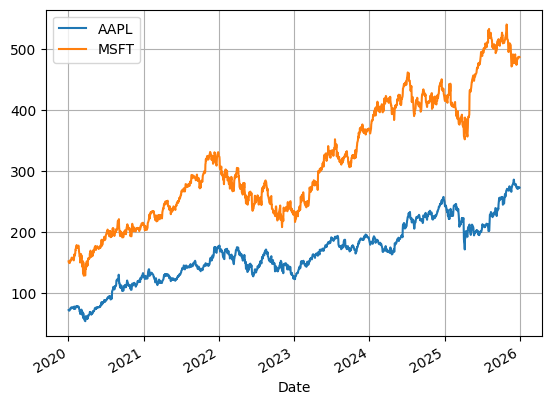

In [93]:
data.plot()
plt.grid()
plt.legend()
plt.show()

### Описательные статистики дневных доходностей

In [94]:
returns.describe()

Ticker,AAPL,MSFT
count,1506.000000,1506.000000
mean,0.001081,0.000945
std,0.020044,0.018618
min,-0.128647,-0.147390
25%,-0.008212,-0.007898
50%,0.001140,0.001110
75%,0.011471,0.010435
max,0.153288,0.142169


### Графики Бокса-Вискера дневных доходностей

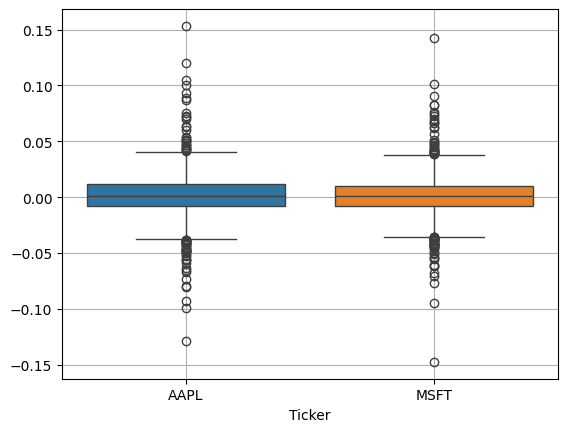

In [95]:
sns.boxplot(returns)
plt.grid()
plt.show()

### Гистограммы распределения дневных доходностей

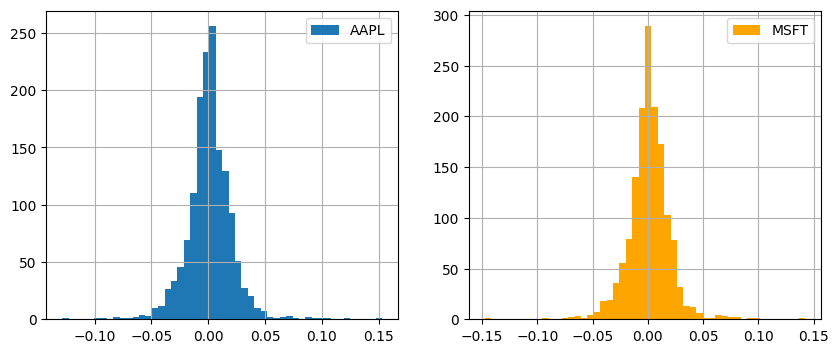

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.hist(returns['AAPL'], bins=50, label='AAPL')
ax1.grid()
ax1.legend()

ax2.hist(returns['MSFT'], bins=50, color='orange', label='MSFT')
ax2.grid()
ax2.legend()

plt.show()

### График доходностей

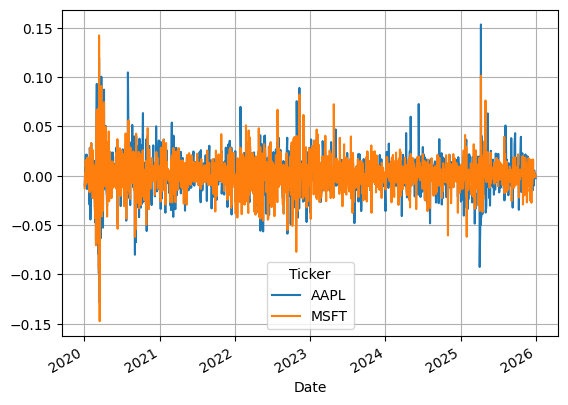

In [97]:
returns.plot()
plt.grid()
plt.show()

In [98]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test ({title}):')
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[4]}')
    print('Reject H0 (Stationary)' if result[1] <= 0.05 else 'Fail to Reject H0 (Non-Stationary)')
    print('---')

def kpss_test(series, title=''):
    print(f'KPSS Test ({title}):')
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[3]}')
    print('Fail to Reject H0 (Stationary)' if result[1] <= 0.05 else 'Reject H0 (Non-Stationary)')
    print('---')

# Применяем тесты к доходностям
for ticker in tickers:
    adf_test(returns[ticker], title=ticker)
    kpss_test(returns[ticker], title=ticker)

Augmented Dickey-Fuller Test (MSFT):
ADF Statistic: -12.496278
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.434725783926551), '5%': np.float64(-2.863472629385615), '10%': np.float64(-2.567798908763865)}
Reject H0 (Stationary)
---
KPSS Test (MSFT):
KPSS Statistic: 0.073989
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---
Augmented Dickey-Fuller Test (AAPL):
ADF Statistic: -13.096204
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.434725783926551), '5%': np.float64(-2.863472629385615), '10%': np.float64(-2.567798908763865)}
Reject H0 (Stationary)
---
KPSS Test (AAPL):
KPSS Statistic: 0.098030
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---


/var/folders/_r/xsq315px3ggfhq10dxmkl3fr0000gn/T/ipykernel_26030/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/_r/xsq315px3ggfhq10dxmkl3fr0000gn/T/ipykernel_26030/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


In [ ]:
from arch import arch_model

model = arch_model(returns)